In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skimage as ski
import bm3d
import os
import importlib
import optics as op
from noise import gauss_noise, poisson_noise, salt_pepper_noise, mix_noise

<Figure size 640x480 with 0 Axes>

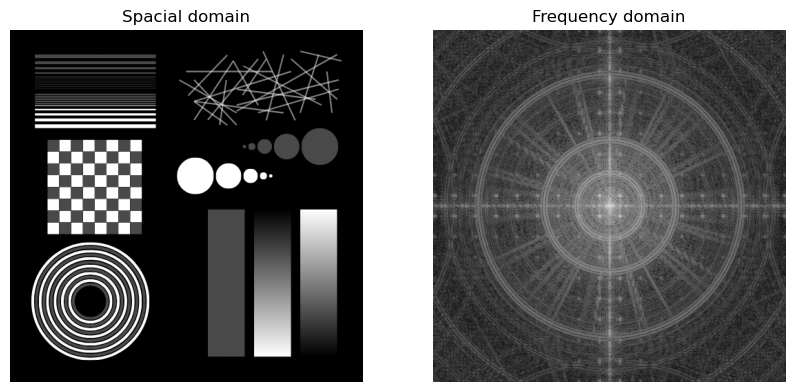

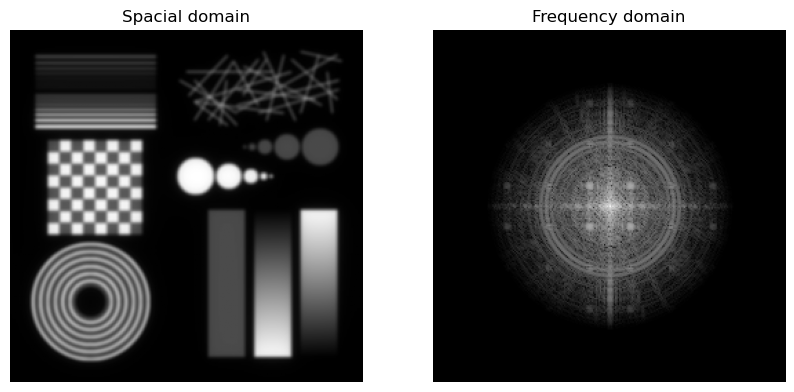

In [10]:
plt.set_cmap('gray')

center_dot_gt = ski.io.imread('source_images\center_dot.tif')
dotted_gt = ski.io.imread('source_images\dotted_line.tif')
synthetic_gt = ski.img_as_float(ski.color.rgb2gray(ski.io.imread('source_images\Synthetic512.png')))

image = synthetic_gt
widefield = op.otf_incoherent(image, NA=1.2, wavelength=680, pixelsize=100)

op.display_fourier(image)
op.display_fourier(widefield)

In [11]:
importlib.reload(op)
# illuminated = np.zeros((9, image.shape[0], image.shape[1]))
angleset = [[15, 135, 255], [15, 134, 256], [15, 133, 257], [15, 132, 258], [15, 140, 251]]
phases = [0, 120, 240]

n = 9
     
illuminated = np.zeros((n, image.shape[0], image.shape[1]))
raw_noisefree = np.zeros((n, image.shape[0]//2, image.shape[1]//2))

angles = angleset[4]
for i in range(3):
    for j in range(3):
        illuminated[3*i + j] = image * op.grating(len(image), angle=angles[i],  phase=phases[j], NA=1.2, wavelength=680, pixelsize=100)

raw_noisefree = op.otf_incoherent(illuminated) # Ground truth

print(raw_noisefree.shape)
# Add noise to the images
percentage = 0.05
folder_path = 'output_images/illumination_angles/5percent/'
# gaussian_noisy = gauss_noise(illuminated, percentage)
# poisson_noisy = poisson_noise(illuminated, percentage)
# saltpepper_noisy = salt_pepper_noise(illuminated, percentage)
mix_noisy = mix_noise(illuminated, percentage)

# Apply low-pass filter
# raw_gaussian = op.otf_incoherent(gaussian_noisy, NA=1.2, wavelength=600, pixelsize=100)
# raw_poisson = op.otf_incoherent(poisson_noisy, NA=1.2, wavelength=600, pixelsize=100)
# raw_saltpepper = op.otf_incoherent(saltpepper_noisy, NA=1.2, wavelength=600, pixelsize=100)
raw_mix = op.otf_incoherent(mix_noisy, NA=1.2, wavelength=600, pixelsize=100)

noisy_image = raw_mix

noisy_PSNR = np.zeros(n)
noisy_SSIM = np.zeros(n)

for i in range(n):
    noisy_PSNR[i] = ski.metrics.peak_signal_noise_ratio(raw_noisefree[i], noisy_image[i])
    noisy_SSIM[i] = ski.metrics.structural_similarity(raw_noisefree[i], noisy_image[i], data_range=1)

print("Noisy PSNR: ", np.mean(noisy_PSNR))
print("Noisy SSIM: ", np.mean(noisy_SSIM))

# fig, ax = plt.subplots(3, 3, figsize=(10, 10))
# for i in range(9):
#     r = i//3
#     c = i%3
#     ax[r, c].imshow(raw_mix[i], vmin=0, vmax=1)
#     ax[r, c].axis('off')
# plt.show()
# plt.imshow(np.sum(noisy_image, axis=0))
# plt.show()

(9, 256, 256)
Noisy PSNR:  30.094226984395934
Noisy SSIM:  0.8709288520229078


# Wiener filter
psf = op.gaussian_psf(3)
wiener_raw = np.zeros((9, 256, 256))

balance = 0.00001 # 1% 0.0001

for i in range(9):
    wiener_raw[i] = ski.restoration.wiener(noisy_image[i], psf, balance)

wiener_PSNR = np.zeros(9)
wiener_SSIM = np.zeros(9)

for i in range(9):
    wiener_PSNR[i] = ski.metrics.peak_signal_noise_ratio(raw_noisefree[i], wiener_raw[i])
    wiener_SSIM[i] = ski.metrics.structural_similarity(raw_noisefree[i], wiener_raw[i], data_range=1)
    
print("Wiener PSNR: ", np.mean(wiener_PSNR))
print("Wiener SSIM: ", np.mean(wiener_SSIM))


# Total variation filter
tv_raw = np.zeros((9, 256, 256))

weight = 0.0000001 # 1% 0.0002
for i in range(9):
    tv_raw[i] = ski.restoration.denoise_tv_chambolle(noisy_image[i], weight)

tv_PSNR = np.zeros(9)
tv_SSIM = np.zeros(9)

for i in range(9):
    tv_PSNR[i] = ski.metrics.peak_signal_noise_ratio(raw_noisefree[i], tv_raw[i])
    tv_SSIM[i] = ski.metrics.structural_similarity(raw_noisefree[i], tv_raw[i], data_range=1)

print("TV PSNR: ", np.mean(tv_PSNR))
print("TV SSIM: ", np.mean(tv_SSIM))

# Save images
# ski.io.imsave(os.path.join(folder_path, 'tv_raw.tif'), tv_raw)

# BM3D filter
bm3d_raw = np.zeros((9, 256, 256))
sigma_psd = 0.0001 # 1% 0.001
for i in range(9):
    bm3d_raw[i] = bm3d.bm3d(noisy_image[i], sigma_psd, stage_arg=bm3d.BM3DStages.HARD_THRESHOLDING)

bm3d_PSNR = np.zeros(9)
bm3d_SSIM = np.zeros(9)

for i in range(9):
    bm3d_PSNR[i] = ski.metrics.peak_signal_noise_ratio(raw_noisefree[i], bm3d_raw[i])
    bm3d_SSIM[i] = ski.metrics.structural_similarity(raw_noisefree[i], bm3d_raw[i], data_range=1)

print("BM3D PSNR: ", np.mean(bm3d_PSNR))
print("BM3D SSIM: ", np.mean(bm3d_SSIM))

# Save images
# ski.io.imsave(os.path.join(folder_path, 'bm3d_raw.tif'), bm3d_raw)

In [12]:
# Richardson-Lucy filter
rl_raw = np.zeros((n, 256, 256))
psf = op.gaussian_psf(3)

for i in range(n):
    rl_raw[i] = ski.restoration.richardson_lucy(noisy_image[i], psf, num_iter=30)

rl_PSNR = np.zeros(n)
rl_SSIM = np.zeros(n)

for i in range(n):
    rl_PSNR[i] = ski.metrics.peak_signal_noise_ratio(raw_noisefree[i], rl_raw[i])
    rl_SSIM[i] = ski.metrics.structural_similarity(raw_noisefree[i], rl_raw[i], data_range=1)

print("RL PSNR: ", np.mean(rl_PSNR))
print("RL SSIM: ", np.mean(rl_SSIM))

# Save images
# ski.io.imsave(os.path.join(folder_path, 'rl_raw.tif'), rl_raw)

RL PSNR:  31.284760970523653
RL SSIM:  0.8892740513796838


# Wiener + RL filter
wiener_rl_raw = np.zeros((9, 256, 256))
psf = op.gaussian_psf(3)


for i in range(9):
    wiener_rl_raw[i] = ski.restoration.richardson_lucy(wiener_raw[i], psf, num_iter=30)

wiener_rl_PSNR = np.zeros(9)
wiener_rl_SSIM = np.zeros(9)

for i in range(9):
    wiener_rl_PSNR[i] = ski.metrics.peak_signal_noise_ratio(raw_noisefree[i], wiener_rl_raw[i])
    wiener_rl_SSIM[i] = ski.metrics.structural_similarity(raw_noisefree[i], wiener_rl_raw[i], data_range=1)

print("Wiener + RL PSNR: ", np.mean(wiener_rl_PSNR))
print("Wiener + RL SSIM: ", np.mean(wiener_rl_SSIM))

# RL + Wiener filter
psf = op.gaussian_psf(3)
rl_wiener_raw = np.zeros((9, 256, 256))

balance = 0.00001 # 1% 0.0001

for i in range(9):
    rl_wiener_raw[i] = ski.restoration.wiener(rl_raw[i], psf, balance)

rl_wiener_PSNR = np.zeros(9)
rl_wiener_SSIM = np.zeros(9)

for i in range(9):
    rl_wiener_PSNR[i] = ski.metrics.peak_signal_noise_ratio(raw_noisefree[i], rl_wiener_raw[i])
    rl_wiener_SSIM[i] = ski.metrics.structural_similarity(raw_noisefree[i], rl_wiener_raw[i], data_range=1)
    
print("RL + Wiener PSNR: ", np.mean(rl_wiener_PSNR))
print("RL + Wiener SSIM: ", np.mean(rl_wiener_SSIM))

# RL + RL filter
rl_rl_raw = np.zeros((9, 256, 256))
psf = op.gaussian_psf(3)


for i in range(9):
    rl_rl_raw[i] = ski.restoration.richardson_lucy(rl_raw[i], psf, num_iter=30)

rl_rl_PSNR = np.zeros(9)
rl_rl_SSIM = np.zeros(9)

for i in range(9):
    rl_rl_PSNR[i] = ski.metrics.peak_signal_noise_ratio(raw_noisefree[i], rl_rl_raw[i])
    rl_rl_SSIM[i] = ski.metrics.structural_similarity(raw_noisefree[i], rl_rl_raw[i], data_range=1)

print("RL + RL PSNR: ", np.mean(rl_rl_PSNR))
print("RL + RL SSIM: ", np.mean(rl_rl_SSIM))

# Wiener + Wiener filter
psf = op.gaussian_psf(3)
wiener_wiener_raw = np.zeros((9, 256, 256))

balance = 0.00001 # 1% 0.0001

for i in range(9):
    wiener_wiener_raw[i] = ski.restoration.wiener(wiener_raw[i], psf, balance)

wiener_wiener_PSNR = np.zeros(9)
wiener_wiener_SSIM = np.zeros(9)

for i in range(9):
    wiener_wiener_PSNR[i] = ski.metrics.peak_signal_noise_ratio(raw_noisefree[i], wiener_wiener_raw[i])
    wiener_wiener_SSIM[i] = ski.metrics.structural_similarity(raw_noisefree[i], wiener_wiener_raw[i], data_range=1)
    
print("Wiener + Wiener PSNR: ", np.mean(wiener_wiener_PSNR))
print("Wiener + Wiener SSIM: ", np.mean(wiener_wiener_SSIM))

data = {
    'Filter': ['Noisy', 'Wiener', 'TV', 'BM3D', 'RL', 'Wiener + RL', 'RL + Wiener', 'RL + RL', 'Wiener + Wiener'],
    'PSNR': [np.mean(noisy_PSNR), np.mean(wiener_PSNR), np.mean(tv_PSNR), np.mean(bm3d_PSNR), np.mean(rl_PSNR), np.mean(wiener_rl_PSNR), np.mean(rl_wiener_PSNR), np.mean(rl_rl_PSNR), np.mean(wiener_wiener_PSNR)],
    'SSIM': [np.mean(noisy_SSIM), np.mean(wiener_SSIM), np.mean(tv_SSIM), np.mean(bm3d_SSIM), np.mean(rl_SSIM), np.mean(wiener_rl_SSIM), np.mean(rl_wiener_SSIM), np.mean(rl_rl_SSIM), np.mean(wiener_wiener_SSIM)],
}

# Create a DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
print("Noisy PSNR: ", np.mean(noisy_PSNR))
print("Noisy SSIM: ", np.mean(noisy_SSIM))
display(df)

# Save all data
save = 1
if save:
    all_filters_raw = np.stack([noisy_image, wiener_raw, tv_raw, bm3d_raw, rl_raw, wiener_rl_raw, rl_wiener_raw, wiener_wiener_raw, rl_rl_raw])
    ski.io.imsave(os.path.join(folder_path, 'mix_0_1_percent.tif'), all_filters_raw)
    df.to_csv(os.path.join(folder_path, 'raw_mix_0_1_percent.csv'), index=False)

ski.io.imsave(os.path.join(folder_path, 'raw_noisefree.tif'), raw_noisefree)


In [13]:
data = {
    'Filter': ['Noisy', 'RL'],
    'PSNR': [np.mean(noisy_PSNR), np.mean(rl_PSNR)],
    'SSIM': [np.mean(noisy_SSIM), np.mean(rl_SSIM)],
}

# Create a DataFrame
df = pd.DataFrame(data)
display(df)

# Save all data
save = 1
if save:
    all_filters_raw = np.stack([noisy_image, rl_raw])
    ski.io.imsave(os.path.join(folder_path, 'angle4.tif'), all_filters_raw)
    df.to_csv(os.path.join(folder_path, 'raw_angle4.csv'), index=False)

# ski.io.imsave(os.path.join(folder_path, 'raw_noisefree_angle1.tif'), raw_noisefree)


,Filter,PSNR,SSIM
0,Noisy,30.094227,0.870929
1,RL,31.284761,0.889274
